In [ ]:
# Dataset Description
# Source: U.S. Chronic Disease Indicators (data.gov)
# Type: Public health dataset
# Rows: (check using df.shape)
# Columns: (check using df.shape)
# Features include:
# Location
# Disease type
# Age group
# Gender
# Health indicators
# Goal: Predict high-risk disease cases
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
drive.mount('/content/drive/')

# Read the dataset
df = pd.read_csv("/content/drive/MyDrive/U.S._Chronic_Disease_Indicators.csv")

# Display first 5 rows
df.head()

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


,YearStart,YearEnd,LocationAbbr,LocationDesc,DataSource,Topic,Question,Response,DataValueUnit,DataValueType,...,TopicID,QuestionID,ResponseID,DataValueTypeID,StratificationCategoryID1,StratificationID1,StratificationCategoryID2,StratificationID2,StratificationCategoryID3,StratificationID3
0,2020,2020,US,United States,BRFSS,Health Status,Recent activity limitation among adults,NaN,Number,Age-adjusted Mean,...,HEA,HEA04,NaN,AGEADJMEAN,SEX,SEXF,NaN,NaN,NaN,NaN
1,2015,2019,AR,Arkansas,US Cancer DVT,Cancer,"Invasive cancer (all sites combined), incidence",NaN,Number,Number,...,CAN,CAN07,NaN,NMBR,SEX,SEXM,NaN,NaN,NaN,NaN
2,2015,2019,CA,California,US Cancer DVT,Cancer,"Cervical cancer mortality among all females, u...",NaN,Number,Number,...,CAN,CAN03,NaN,NMBR,OVERALL,OVR,NaN,NaN,NaN,NaN
3,2015,2019,CO,Colorado,US Cancer DVT,Cancer,"Invasive cancer (all sites combined), incidence",NaN,Number,Number,...,CAN,CAN07,NaN,NMBR,RACE,HIS,NaN,NaN,NaN,NaN
4,2015,2019,GA,Georgia,US Cancer DVT,Cancer,"Prostate cancer mortality among all males, und...",NaN,Number,Number,...,CAN,CAN05,NaN,NMBR,RACE,WHT,NaN,NaN,NaN,NaN


In [ ]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 309215 entries, 0 to 309214
Data columns (total 34 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   YearStart                  309215 non-null  int64  
 1   YearEnd                    309215 non-null  int64  
 2   LocationAbbr               309215 non-null  object 
 3   LocationDesc               309215 non-null  object 
 4   DataSource                 309215 non-null  object 
 5   Topic                      309215 non-null  object 
 6   Question                   309215 non-null  object 
 7   Response                   0 non-null       float64
 8   DataValueUnit              309215 non-null  object 
 9   DataValueType              309215 non-null  object 
 10  DataValue                  209196 non-null  float64
 11  DataValueAlt               209196 non-null  float64
 12  DataValueFootnoteSymbol    101716 non-null  object 
 13  DataValueFootnote          10

In [ ]:
df.describe()

,YearStart,YearEnd,Response,DataValue,DataValueAlt,LowConfidenceLimit,HighConfidenceLimit,StratificationCategory2,Stratification2,StratificationCategory3,Stratification3,LocationID,ResponseID,StratificationCategoryID2,StratificationID2,StratificationCategoryID3,StratificationID3
count,309215.000000,309215.000000,0.0,2.091960e+05,2.091960e+05,188885.000000,188890.000000,0.0,0.0,0.0,0.0,309215.000000,0.0,0.0,0.0,0.0,0.0
mean,2020.012195,2020.288540,NaN,6.943569e+02,7.356701e+02,36.825051,46.030554,NaN,NaN,NaN,NaN,31.208693,NaN,NaN,NaN,NaN,NaN
std,1.530835,1.068591,NaN,1.620341e+04,1.834715e+04,65.025590,69.995643,NaN,NaN,NaN,NaN,17.798773,NaN,NaN,NaN,NaN,NaN
min,2015.000000,2019.000000,NaN,0.000000e+00,0.000000e+00,0.000000,0.000000,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN
25%,2019.000000,2019.000000,NaN,1.240000e+01,1.240000e+01,9.100000,14.000000,NaN,NaN,NaN,NaN,17.000000,NaN,NaN,NaN,NaN,NaN
50%,2020.000000,2020.000000,NaN,2.700000e+01,2.700000e+01,19.500000,29.200000,NaN,NaN,NaN,NaN,31.000000,NaN,NaN,NaN,NaN,NaN
75%,2021.000000,2021.000000,NaN,5.780000e+01,5.780000e+01,40.300000,54.300000,NaN,NaN,NaN,NaN,45.000000,NaN,NaN,NaN,NaN,NaN
max,2022.000000,2022.000000,NaN,2.925456e+06,2.925456e+06,1427.000000,1485.900000,NaN,NaN,NaN,NaN,78.000000,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.isnull().sum()

,0
YearStart,0
YearEnd,0
LocationAbbr,0
LocationDesc,0
DataSource,0
Topic,0
Question,0
Response,309215
DataValueUnit,0
DataValueType,0


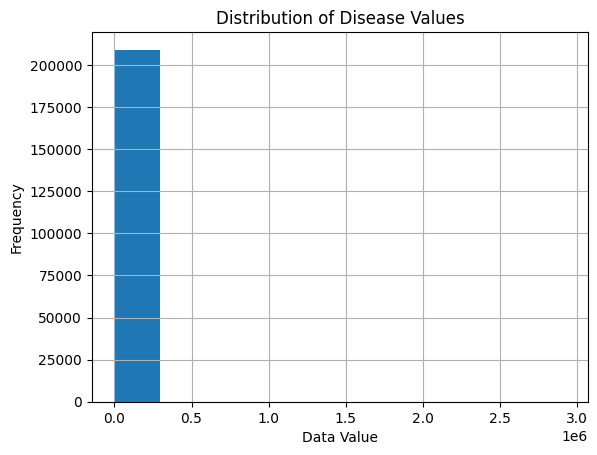

In [20]:
#Univariate Visualization
import matplotlib.pyplot as plt
df['DataValue'].dropna().hist()
plt.title('Distribution of Disease Values')
plt.xlabel('Data Value')
plt.ylabel('Frequency')
plt.show()

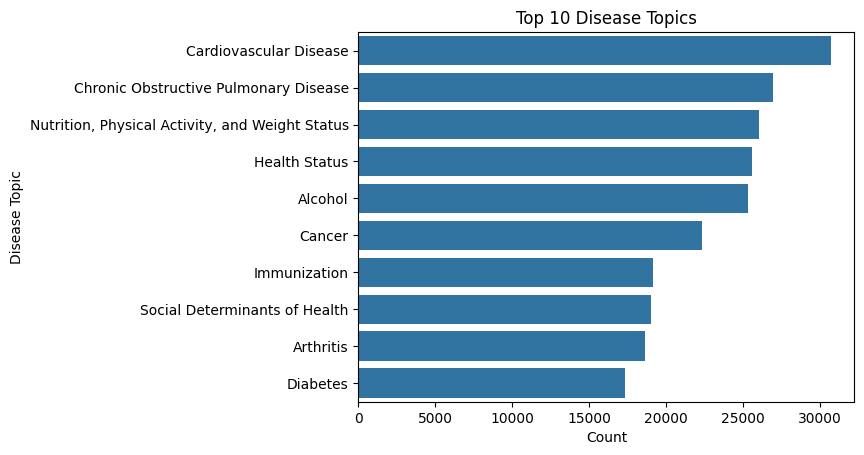

In [70]:
import seaborn as sns
top_topics = df['Topic'].value_counts().head(10)
sns.barplot(x=top_topics.values, y=top_topics.index)
plt.title('Top 10 Disease Topics')
plt.xlabel('Count')
plt.ylabel('Disease Topic')
plt.show()

In [32]:
df['Stratification1'].unique()

array(['Female', 'Male', 'Overall', 'Hispanic', 'White, non-Hispanic',
       'Age >=65', 'Black, non-Hispanic',
       'Asian or Pacific Islander, non-Hispanic', 'Age 6-14', 'Age 12-17',
       'Age 4 m - 5 y', 'Age 18-44', 'Grade 12',
       'Hawaiian or Pacific Islander, non-Hispanic', 'Age 45-64',
       'Asian, non-Hispanic', 'Multiracial, non-Hispanic', 'Grade 10',
       'Age 0-44', 'American Indian or Alaska Native, non-Hispanic',
       'Grade 11', 'Grade 9', 'Age 1-5', 'Age 6-9', 'Age 10-13',
       'Age 6-11'], dtype=object)

In [39]:
df_gender = df[df['Stratification1'].isin(['Male', 'Female'])]

In [62]:
# Clean spaces
df['Stratification1'] = df['Stratification1'].str.strip()

# Keep only Male & Female
df_gender = df[df['Stratification1'].isin(['Male', 'Female'])]

# Drop missing values
df_gender = df_gender.dropna(subset=['DataValue', 'Topic', 'LocationDesc'])

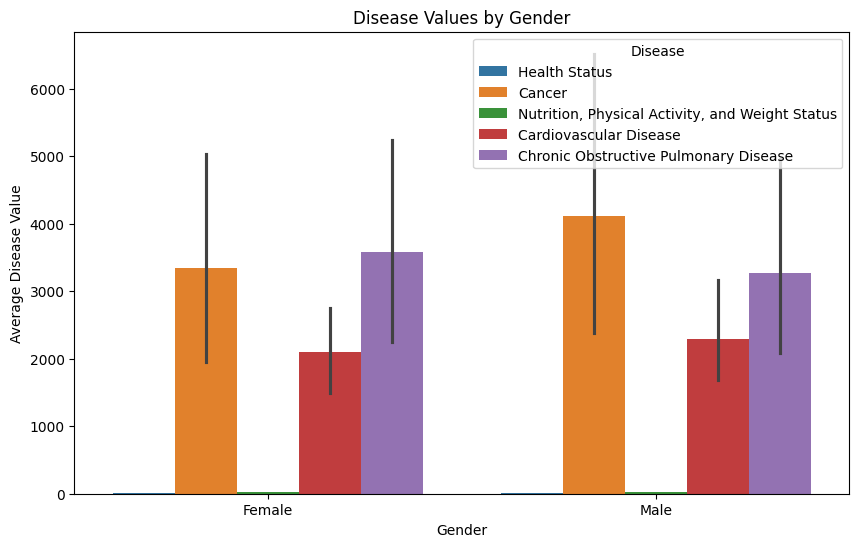

In [63]:
import seaborn as sns
import matplotlib.pyplot as plt

# Focus on top diseases (to avoid clutter)
top_diseases = df_gender['Topic'].value_counts().head(5).index
filtered = df_gender[df_gender['Topic'].isin(top_diseases)]

plt.figure(figsize=(10,6))
sns.barplot(x='Stratification1', y='DataValue', hue='Topic', data=filtered)

plt.title('Disease Values by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Disease Value')
plt.legend(title='Disease')
plt.show()

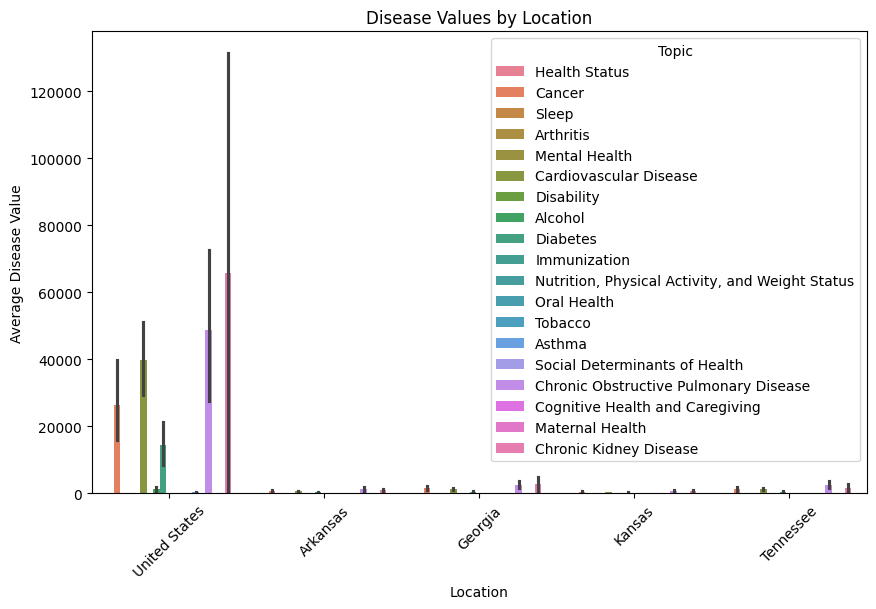

In [81]:
# Top locations to keep graph readable
top_locations = df['LocationDesc'].value_counts().head(5).index
filtered_loc = df[df['LocationDesc'].isin(top_locations)]

plt.figure(figsize=(10,6))
sns.barplot(x='LocationDesc', y='DataValue', hue='Topic', data=filtered_loc)

plt.title('Disease Values by Location')
plt.xlabel('Location')
plt.ylabel('Average Disease Value')
plt.xticks(rotation=45)
plt.show()

In [65]:
df['StratificationCategory1'].unique()

array(['Sex', 'Overall', 'Race/Ethnicity', 'Age', 'Grade'], dtype=object)

In [66]:
df_race = df[df['StratificationCategory1'] == 'Race/Ethnicity']

In [67]:
df_race = df_race.dropna(subset=['DataValue', 'Stratification1', 'Topic'])
df_race['Stratification1'] = df_race['Stratification1'].str.strip()

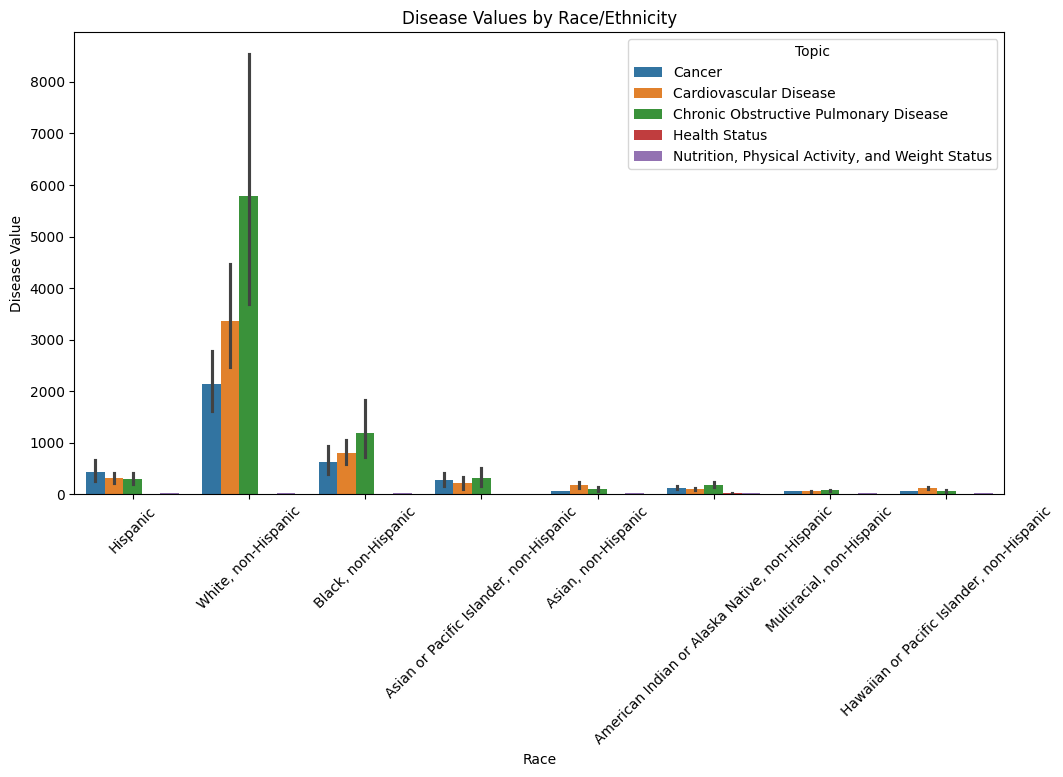

In [82]:
# Top diseases
top_diseases = df_race['Topic'].value_counts().head(5).index
filtered = df_race[df_race['Topic'].isin(top_diseases)]

plt.figure(figsize=(12,6))
sns.barplot(x='Stratification1', y='DataValue', hue='Topic', data=filtered)

plt.title('Disease Values by Race/Ethnicity')
plt.xlabel('Race')
plt.ylabel('Disease Value')
plt.xticks(rotation=45)
plt.show()

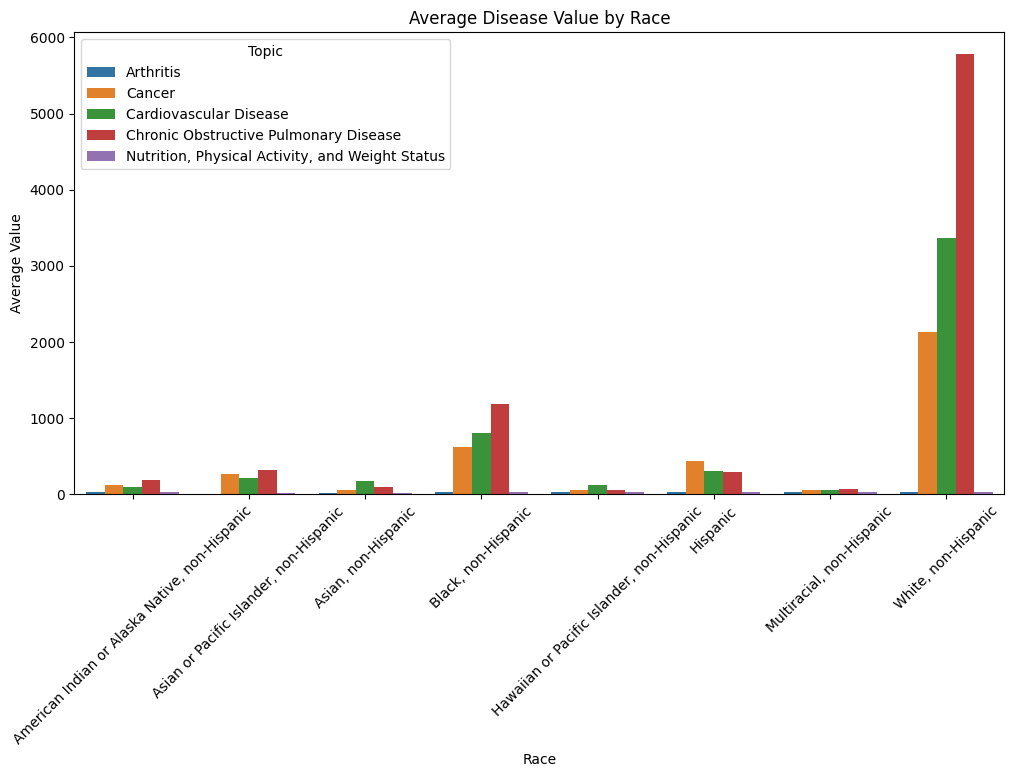

In [71]:
grouped_race = df_race.groupby(['Stratification1','Topic'])['DataValue'].mean().reset_index()

top_diseases = grouped_race['Topic'].value_counts().head(5).index
grouped_race = grouped_race[grouped_race['Topic'].isin(top_diseases)]

plt.figure(figsize=(12,6))
sns.barplot(x='Stratification1', y='DataValue', hue='Topic', data=grouped_race)

plt.title('Average Disease Value by Race')
plt.xlabel('Race')
plt.ylabel('Average Value')
plt.xticks(rotation=45)
plt.show()